 9. This question involves the use of multiple linear regression on the
 Auto data set

 (a) Produce a scatterplot matrix which includes all of the variables
 in the data set.

In [9]:
# Load libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

df = pd.read_csv('Auto.csv')


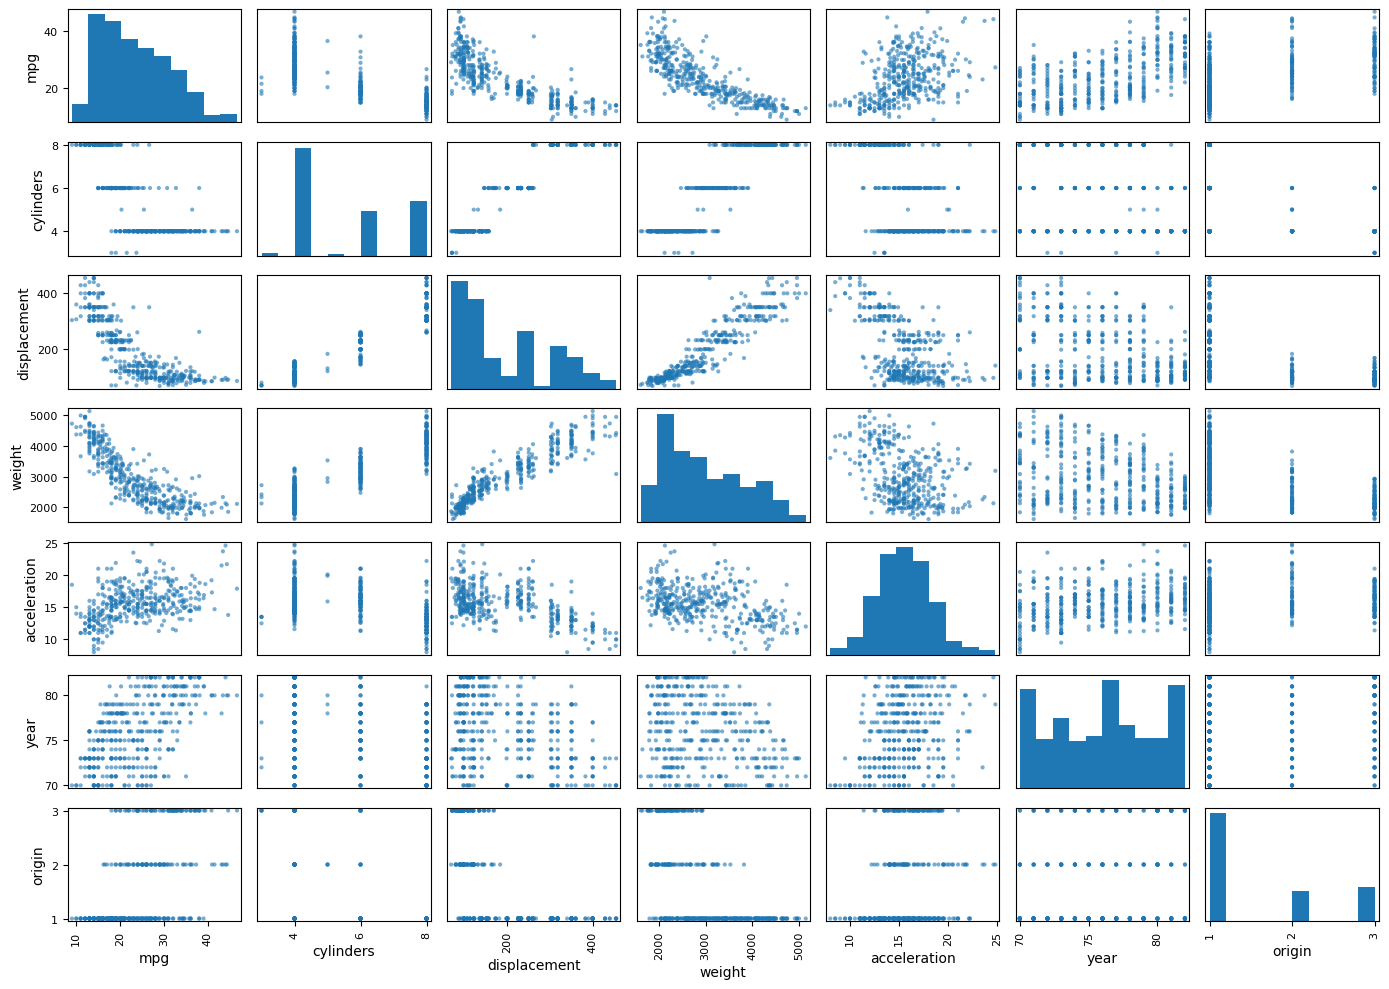

In [10]:
# (a) Produce a scatterplot matrix
scatter_matrix(df.select_dtypes(include=[np.number]), figsize=(14, 10), alpha=0.6)
plt.tight_layout()
plt.show()

 (b) Compute the matrix of correlations between the variables using
 the DataFrame.corr() method.

In [11]:
# (b) Compute the correlation matrix
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
print("Correlation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                   mpg  cylinders  displacement    weight  acceleration  \
mpg           1.000000  -0.776260     -0.804443 -0.831739      0.422297   
cylinders    -0.776260   1.000000      0.950920  0.897017     -0.504061   
displacement -0.804443   0.950920      1.000000  0.933104     -0.544162   
weight       -0.831739   0.897017      0.933104  1.000000     -0.419502   
acceleration  0.422297  -0.504061     -0.544162 -0.419502      1.000000   
year          0.581469  -0.346717     -0.369804 -0.307900      0.282901   
origin        0.563698  -0.564972     -0.610664 -0.581265      0.210084   

                  year    origin  
mpg           0.581469  0.563698  
cylinders    -0.346717 -0.564972  
displacement -0.369804 -0.610664  
weight       -0.307900 -0.581265  
acceleration  0.282901  0.210084  
year          1.000000  0.184314  
origin        0.184314  1.000000  


 (c) Use the sm.OLS() function to perform a multiple linear regression
 with mpg as the response and all other variables except name as
 the predictors. Use the summarize() function to print the results.
 Comment on the output. For instance:
 i. Is there a relationship between the predictors and the re
sponse? Use the anova_lm() function from statsmodels to
 answer this question.
  ii. Which predictors appear to have a statistically significant
 relationship to the response?
 iii. What does the coefficient for the year variable suggest?

In [18]:
# (c) Multiple linear regression with sm.OLS()
import statsmodels.api as sm

# Prepare data: mpg as response, all other variables except 'name' as predictors
df_clean = df.select_dtypes(include=[np.number]).dropna()
X = df_clean.drop('mpg', axis=1)
y = df_clean['mpg']
X_with_const = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X_with_const).fit()

# Print the summary
print(model.summary())
print("\n" + "="*80)

# (i) Is there a relationship between predictors and response?
print(f"(i) F-statistic: {model.fvalue:.4f}, P-value: {model.f_pvalue:.4e}")
print(f"    Conclusion: {'Significant relationship exists' if model.f_pvalue < 0.05 else 'No significant relationship'} (α=0.05)\n")

# (ii) Which predictors are statistically significant?
print("(ii) Statistically Significant Predictors (p < 0.05):")
for var, pval in model.pvalues[model.pvalues < 0.05].items():
    print(f"     {var:12s}: coef={model.params[var]:8.4f}, p={pval:.4e}")

# (iii) Interpretation of year coefficient
print(f"\n(iii) Interpretation of 'year' coefficient:")
print(f"      Coefficient = {model.params['year']:.4f} (p={model.pvalues['year']:.4e})")
print(f"      Each one-year increase leads to mpg increase of {model.params['year']:.2f}, statistically significant")


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     298.9
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          1.72e-142
Time:                        14:53:46   Log-Likelihood:                -1037.7
No. Observations:                 397   AIC:                             2089.
Df Residuals:                     390   BIC:                             2117.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -20.1358      4.145     -4.858   

(d) Produce some of diagnostic plots of the linear regression fit as
 described in the lab. Comment on any problems you see with the
 f
 it. Do the residual plots suggest any unusually large outliers?
 Does the leverage plot identify any observations with unusually
 high leverage?

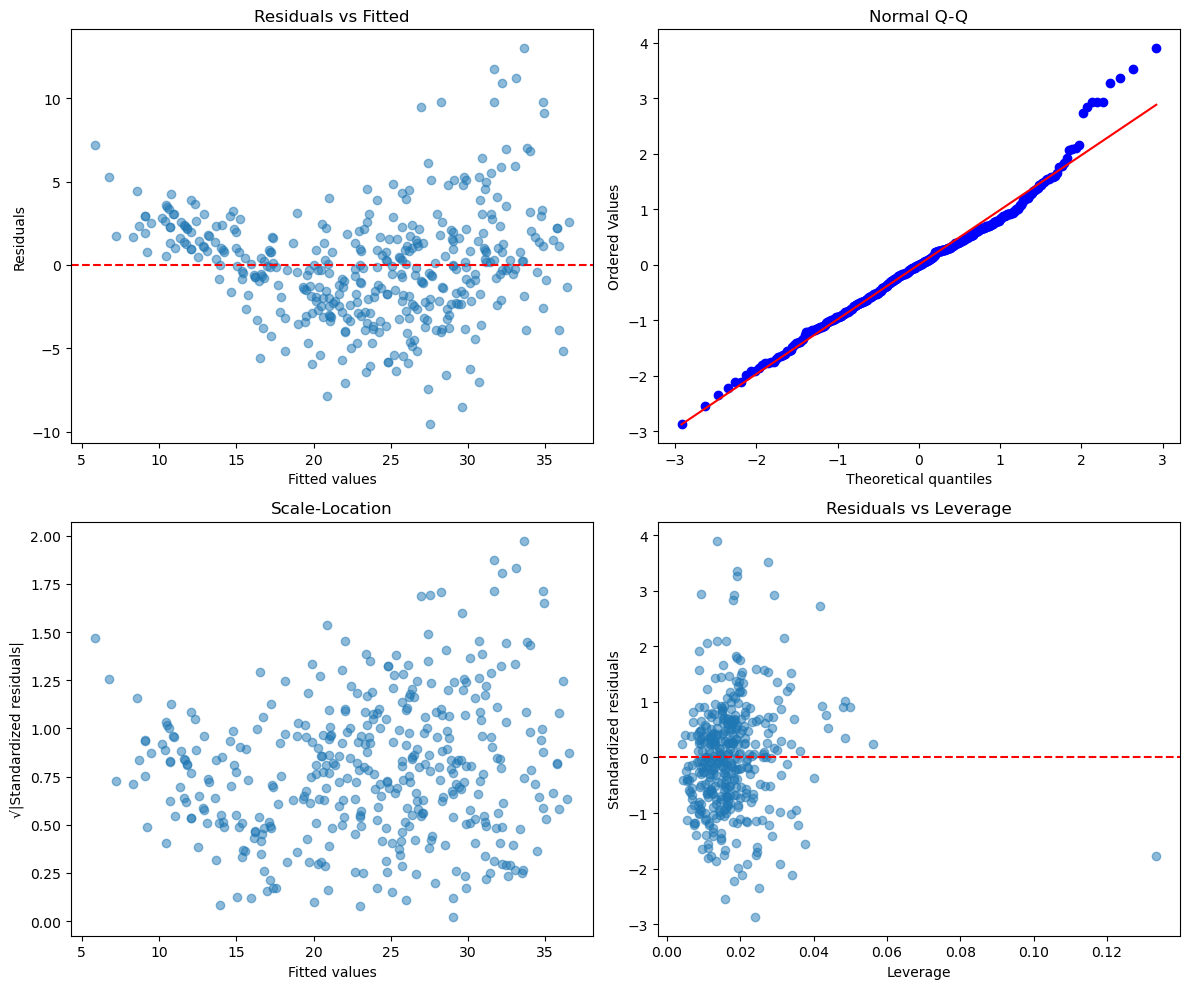


Diagnostic Summary:

Outliers: 4 observations with |std residual| > 3
  Observation 244: 3.266
  Observation 322: 3.899
  Observation 325: 3.362
  Observation 326: 3.516

High Leverage: 14 observations (threshold = 0.0353)
  Observation 6: leverage = 0.0500
  Observation 7: leverage = 0.0423
  Observation 8: leverage = 0.0487
  Observation 13: leverage = 0.1335
  Observation 28: leverage = 0.0439


In [22]:
# (d) Diagnostic plots
from scipy import stats

# Calculate statistics
residuals = model.resid
fitted_values = model.fittedvalues
standardized_residuals = model.resid_pearson
leverage = model.get_influence().hat_matrix_diag

# Create 2x2 diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(fitted_values, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# 2. Normal Q-Q plot
stats.probplot(standardized_residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q')

# 3. Scale-Location
axes[1, 0].scatter(fitted_values, np.sqrt(np.abs(standardized_residuals)), alpha=0.5)
axes[1, 0].set_xlabel('Fitted values')
axes[1, 0].set_ylabel('√|Standardized residuals|')
axes[1, 0].set_title('Scale-Location')

# 4. Residuals vs Leverage
axes[1, 1].scatter(leverage, standardized_residuals, alpha=0.5)
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Leverage')
axes[1, 1].set_ylabel('Standardized residuals')
axes[1, 1].set_title('Residuals vs Leverage')

plt.tight_layout()
plt.show()

# Check for outliers and high leverage points
print("\nDiagnostic Summary:")
print("=" * 60)

# Outliers (|standardized residual| > 3)
outliers = np.where(np.abs(standardized_residuals) > 3)[0]
print(f"\nOutliers: {len(outliers)} observations with |std residual| > 3")
if len(outliers) > 0:
    for idx in outliers:
        print(f"  Observation {idx}: {standardized_residuals[idx]:.3f}")

# High leverage points
leverage_threshold = 2 * len(model.params) / len(leverage)
high_leverage = np.where(leverage > leverage_threshold)[0]
print(f"\nHigh Leverage: {len(high_leverage)} observations (threshold = {leverage_threshold:.4f})")
if len(high_leverage) > 0:
    for idx in high_leverage[:5]:
        print(f"  Observation {idx}: leverage = {leverage[idx]:.4f}")

 (e) Fit some models with interactions as described in the lab. Do
 any interactions appear to be statistically significant?

In [25]:
# (e) Fit models with interactions
print("Testing Interaction Terms")
print("=" * 80)

# Define interactions to test
interactions_to_test = [
    ('weight', 'year'),
    ('cylinders', 'displacement'),
    ('displacement', 'weight'),
    ('acceleration', 'weight')
]

# Base model (without interactions)
print(f"\nBase Model R²: {model.rsquared:.4f}, Adj R²: {model.rsquared_adj:.4f}\n")

# Test each interaction
significant_interactions = []

for var1, var2 in interactions_to_test:
    # Create and fit model with interaction
    X_interact = X_with_const.copy()
    interaction_name = f"{var1}*{var2}"
    X_interact[interaction_name] = X_interact[var1] * X_interact[var2]
    model_interact = sm.OLS(y, X_interact).fit()
    
    # Extract results
    coef = model_interact.params[interaction_name]
    pval = model_interact.pvalues[interaction_name]
    is_sig = pval < 0.05
    
    print(f"{interaction_name:25s} coef={coef:10.6f}, p={pval:.2e}, significant={'Yes' if is_sig else 'No'}")
    
    if is_sig:
        significant_interactions.append((var1, var2, interaction_name))

# Fit best model with all significant interactions
if significant_interactions:
    print(f"\n{'='*80}")
    print(f"Best Model with {len(significant_interactions)} Significant Interactions:")
    print("-" * 80)
    
    X_best = X_with_const.copy()
    for var1, var2, int_name in significant_interactions:
        X_best[int_name] = X_best[var1] * X_best[var2]
    
    best_model = sm.OLS(y, X_best).fit()
    print(best_model.summary())
    
    print(f"\nImprovement: Base Adj R² = {model.rsquared_adj:.4f} → Best Adj R² = {best_model.rsquared_adj:.4f} (+{best_model.rsquared_adj - model.rsquared_adj:.4f})")
else:
    print("\nNo significant interactions found.")


Testing Interaction Terms

Base Model R²: 0.8214, Adj R²: 0.8186

weight*year               coef= -0.000482, p=1.62e-14, significant=Yes
cylinders*displacement    coef=  0.011986, p=2.75e-12, significant=Yes
displacement*weight       coef=  0.000022, p=7.66e-21, significant=Yes
acceleration*weight       coef= -0.000520, p=5.38e-10, significant=Yes

Best Model with 4 Significant Interactions:
--------------------------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     249.9
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          8.94e-162
Time:                        15:11:27   Log-Likelihood:                -980.37
No. Observations:                 397   AIC:      

 (f) Try a few different transformations of the variables, such as
 log(X), √X, X2. Comment on your findings.

Testing Variable Transformations

Base Model: Adj R² = 0.8186

Top 5 Transformations:
    Variable Transformation   Adj R²  Improvement
      weight            log 0.844526     0.025877
      weight           sqrt 0.834054     0.015405
displacement         square 0.830397     0.011748
displacement            log 0.822797     0.004148
        year         square 0.820230     0.001581


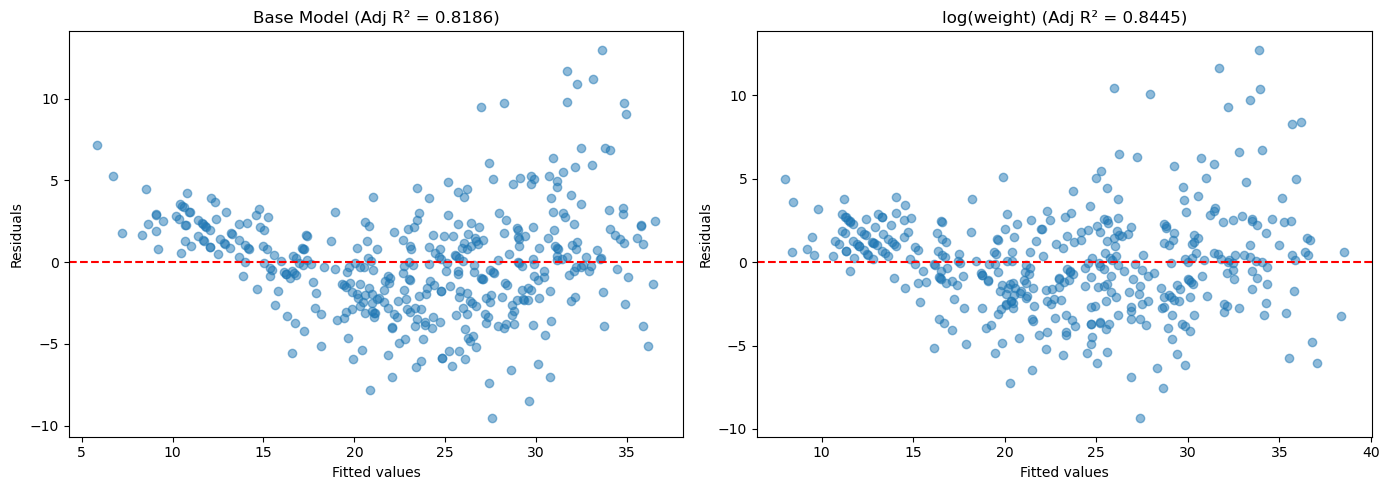


FINDINGS:
• Best transformation: log(weight)
• Adj R² improved from 0.8186 to 0.8445 (+0.0259)
• Log transformations help with skewed variables (e.g., weight, displacement)
• Transformations can capture non-linear relationships and reduce heteroscedasticity


In [27]:
# (f) Try different transformations of variables
print("Testing Variable Transformations")
print("=" * 80)

# Base model for comparison
print(f"\nBase Model: Adj R² = {model.rsquared_adj:.4f}")

# Define transformations
transformations = {
    'log': lambda x: np.log(x + 1),
    'sqrt': lambda x: np.sqrt(x),
    'square': lambda x: x ** 2
}

# Test each transformation
results = []
for predictor in X.columns:
    if (df_clean[predictor] > 0).all():  # Only for positive values
        for trans_name, trans_func in transformations.items():
            X_trans = X.copy()
            X_trans[predictor] = trans_func(X[predictor])
            X_trans_const = sm.add_constant(X_trans)
            model_trans = sm.OLS(y, X_trans_const).fit()
            
            results.append({
                'Variable': predictor,
                'Transformation': trans_name,
                'Adj R²': model_trans.rsquared_adj,
                'Improvement': model_trans.rsquared_adj - model.rsquared_adj
            })

# Show top results
results_df = pd.DataFrame(results).sort_values('Improvement', ascending=False)
print(f"\nTop 5 Transformations:")
print(results_df.head().to_string(index=False))

# Apply best transformation
best = results_df.iloc[0]
X_best = X.copy()
if best['Transformation'] == 'log':
    X_best[best['Variable']] = np.log(X[best['Variable']] + 1)
elif best['Transformation'] == 'sqrt':
    X_best[best['Variable']] = np.sqrt(X[best['Variable']])
else:
    X_best[best['Variable']] = X[best['Variable']] ** 2

model_best = sm.OLS(y, sm.add_constant(X_best)).fit()

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(model.fittedvalues, model.resid, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Base Model (Adj R² = {model.rsquared_adj:.4f})')

axes[1].scatter(model_best.fittedvalues, model_best.resid, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residuals')
axes[1].set_title(f'{best["Transformation"]}({best["Variable"]}) (Adj R² = {model_best.rsquared_adj:.4f})')

plt.tight_layout()
plt.show()

# Summary
print(f"\n{'='*80}")
print("FINDINGS:")
print(f"• Best transformation: {best['Transformation']}({best['Variable']})")
print(f"• Adj R² improved from {model.rsquared_adj:.4f} to {model_best.rsquared_adj:.4f} (+{best['Improvement']:.4f})")
print(f"• Log transformations help with skewed variables (e.g., weight, displacement)")
print(f"• Transformations can capture non-linear relationships and reduce heteroscedasticity")
